# Controlled A/B/C Ablation for Subject-Independent Keypoint Recognition

This notebook measures improvements in a fixed order before S4 is used: baseline A, handcrafted-feature B, targeted robust C, model lock, S4 evaluation, five-subject LOSO, and final all-five training.

In [1]:
from pathlib import Path
import json, sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix
import sklearn, tsfel

from abc_experiment_pipeline import *
from tsfel_histgb_pipeline import (
    CLASSES, COORD_COLUMNS, WindowFeatures, combine_loso_folds,
    concatenate_window_features, clean_labels, evaluate_predictions,
    fit_estimator, run_loso_fold, save_artifact, select_nonoverlapping_windows,
    validate_pose_columns, write_prediction_outputs,
)

DATA_DIR = Path(r'data/keypointlabel')
S4_SHARED_FILE = Path(r'data/test_data_keypoint_shared.csv')
S4_LABEL_FILE = Path(r'data/keypointlabel/keypoints_with_labels_4.csv')
SUBJECTS_STAGE1 = [1, 2, 3, 5]
ALL_SUBJECTS = [1, 2, 3, 4, 5]
RANDOM_STATE = 42
ARTIFACT_DIR = Path('artifacts/abc_ablation')
CACHE_DIR = ARTIFACT_DIR / 'cache'
OUTPUT_DIR = Path('outputs/abc_ablation')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Python:', sys.executable)
print('TSFEL:', getattr(tsfel, '__version__', '0.2.0'), '| sklearn:', sklearn.__version__)

Python: python
TSFEL: 0.2.0 | sklearn: 1.7.2


## Experimental Controls

- A and B use identical preprocessing, TSFEL domains, windows, folds, model parameters, and random seed.
- B differs from A only by adding handcrafted frame-level signals.
- C adds robust smoothing/scale, symmetric targeted signals, and spectral TSFEL.
- S4 labels are not loaded until the A/B/C winner has been selected.
- Participant-local deterministic preprocessing is allowed before LOSO; imputation, variance filtering, and the classifier are fitted only inside each training fold.

## 1. Data and Schema Validation

In [2]:
training_files = {s: DATA_DIR / f'keypoints_with_labels_{s}.csv' for s in SUBJECTS_STAGE1}
schema = []
for subject, path in training_files.items():
    header = pd.read_csv(path, nrows=2)
    validate_pose_columns(header)
    assert 'Action Label' in header.columns
    schema.append({'subject': subject, 'file': path.name, 'columns': len(header.columns)})
shared_header = pd.read_csv(S4_SHARED_FILE, nrows=2)
validate_pose_columns(shared_header)
display(pd.DataFrame(schema))
print('S4 shared-test columns:', len(shared_header.columns))

,subject,file,columns
0,1,keypoints_with_labels_1.csv,36
1,2,keypoints_with_labels_2.csv,36
2,3,keypoints_with_labels_3.csv,36
3,5,keypoints_with_labels_5.csv,36


S4 shared-test columns: 35


## 2. Experiment Definitions

In [3]:
experiment_table = pd.DataFrame([
    {
        'experiment': name,
        'schema': definition.feature_schema_version,
        'signal_mode': definition.signal_mode,
        'robust_preprocessing': definition.robust_preprocessing,
        'spectral_tsfel': definition.include_spectral,
        'random_state': definition.random_state,
    }
    for name, definition in EXPERIMENTS.items()
])
display(experiment_table)
assert experiment_table['random_state'].eq(RANDOM_STATE).all()

,experiment,schema,signal_mode,robust_preprocessing,spectral_tsfel,random_state
0,A,abc-a-raw-stat-temp-v1,raw,False,False,42
1,B,abc-b-raw-v7-stat-temp-v1,raw_v7,False,False,42
2,C,abc-c-robust-symmetric-spectral-v1,robust_symmetric,True,True,42


In [4]:
def show_fold(fold, title):
    row = {
        'held_out_subject': fold.held_out_subject,
        'n_train_windows': fold.n_train_windows,
        'n_test_windows': fold.n_test_windows,
        **fold.metrics,
    }
    display(pd.DataFrame([row]))
    display(fold.classification_report)
    plt.figure(figsize=(10, 8))
    sns.heatmap(fold.confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

def summarize_experiment(name, result):
    metrics = result.fold_metrics
    worst = metrics.loc[metrics['accuracy'].idxmin()]
    return {
        'experiment': name,
        'mean_fold_accuracy': result.summary['mean_fold_accuracy'],
        'pooled_accuracy': result.summary['pooled_accuracy'],
        'pooled_macro_f1': result.summary['pooled_macro_f1'],
        'pooled_abnormal_f1': result.summary['pooled_abnormal_f1'],
        'worst_subject': int(worst['held_out_subject']),
        'worst_subject_accuracy': float(worst['accuracy']),
    }

def top_confusions(result, limit=10):
    rows = []
    for true_index, true_label in enumerate(CLASSES):
        for pred_index, predicted_label in enumerate(CLASSES):
            count = int(result.confusion.iloc[true_index, pred_index])
            if true_index != pred_index and count:
                rows.append({'true_label': true_label, 'predicted_label': predicted_label, 'windows': count})
    return pd.DataFrame(rows).sort_values('windows', ascending=False).head(limit)

## 3. Shared Preprocessing and Experiment B Extraction

In [5]:
windows_b = {}
for subject, path in training_files.items():
    print(f'Experiment B: loading/extracting subject {subject}', flush=True)
    windows_b[subject] = load_or_extract_experiment_subject(path, subject, 'B', CACHE_DIR)
display(pd.DataFrame({s: w.y.value_counts() for s, w in windows_b.items()}).fillna(0).astype(int))
print('Experiment B shapes:', {s: w.x.shape for s, w in windows_b.items()})

Experiment B: loading/extracting subject 1


Experiment B: loading/extracting subject 2


Experiment B: loading/extracting subject 3


Experiment B: loading/extracting subject 5


,1,2,3,5
Action Label,,,,
Attacking,58,76,69,59
Biting,73,37,118,74
Eating snacks,195,195,140,188
Head banging,50,52,80,52
Sitting quietly,190,195,365,198
Throwing things,59,52,49,51
Using phone,144,146,321,134
Walking,194,192,267,189


Experiment B shapes: {1: (963, 1610), 2: (945, 1610), 3: (1409, 1610), 5: (945, 1610)}


## 4. Experiment A: Raw Normalized Keypoints

In [6]:
windows_a = {}
for subject, path in training_files.items():
    windows_a[subject] = derive_experiment_a_windows(windows_b[subject])
    save_experiment_cache(CACHE_DIR, path, subject, 'A', windows_a[subject])
print('Experiment A shapes:', {s: w.x.shape for s, w in windows_a.items()})

Experiment A shapes: {1: (963, 782), 2: (945, 782), 3: (1409, 782), 5: (945, 782)}


### Experiment A - Held-Out S1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.545643,0.476734,0.663594,0.742268,0.6


,precision,recall,f1-score,support
Attacking,0.153846,0.137931,0.145455,29.000000
Biting,0.000000,0.000000,0.000000,36.000000
Eating snacks,0.384615,0.510204,0.438596,98.000000
Head banging,0.705882,0.960000,0.813559,25.000000
Sitting quietly,0.388430,0.494737,0.435185,95.000000
Throwing things,0.567568,0.700000,0.626866,30.000000
Using phone,1.000000,0.277778,0.434783,72.000000
Walking,0.850877,1.000000,0.919431,97.000000
accuracy,0.545643,0.545643,0.545643,0.545643
macro avg,0.506402,0.510081,0.476734,482.000000


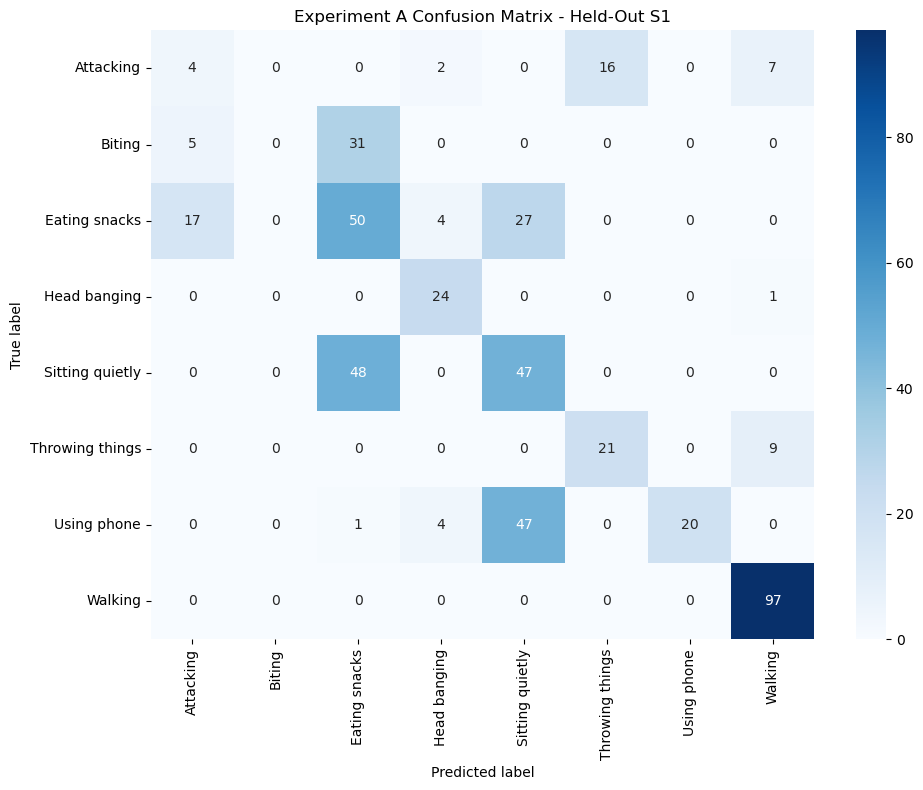

In [7]:
a_s1 = run_loso_fold(windows_a, held_out_subject=1, random_state=RANDOM_STATE)
a_s1.confusion.to_csv(ARTIFACT_DIR / 'a_confusion_subject_1.csv')
show_fold(a_s1, 'Experiment A Confusion Matrix - Held-Out S1')

### Experiment A - Held-Out S2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,3317,472,0.620763,0.502038,0.693182,0.897059,0.564815


,precision,recall,f1-score,support
Attacking,0.800000,0.210526,0.333333,38.000000
Biting,0.000000,0.000000,0.000000,18.000000
Eating snacks,0.662921,0.608247,0.634409,97.000000
Head banging,0.650000,1.000000,0.787879,26.000000
Sitting quietly,0.549133,0.969388,0.701107,98.000000
Throwing things,0.846154,0.423077,0.564103,26.000000
Using phone,0.020833,0.013699,0.016529,73.000000
Walking,0.989362,0.968750,0.978947,96.000000
accuracy,0.620763,0.620763,0.620763,0.620763
macro avg,0.564800,0.524211,0.502038,472.000000


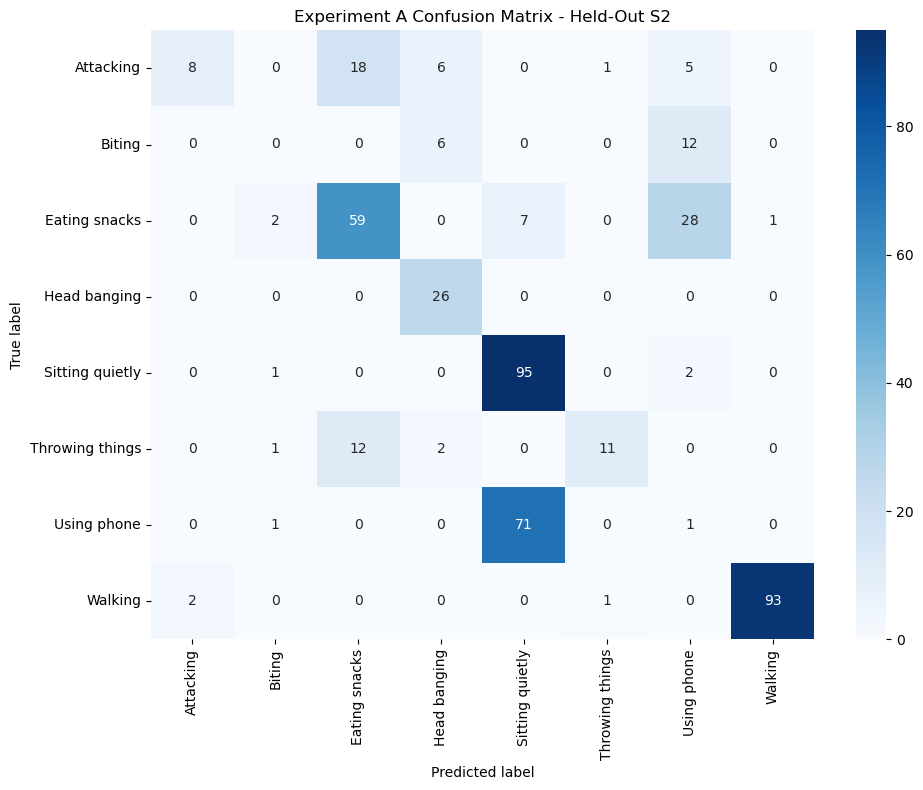

In [8]:
a_s2 = run_loso_fold(windows_a, held_out_subject=2, random_state=RANDOM_STATE)
a_s2.confusion.to_csv(ARTIFACT_DIR / 'a_confusion_subject_2.csv')
show_fold(a_s2, 'Experiment A Confusion Matrix - Held-Out S2')

### Experiment A - Held-Out S3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,2853,703,0.398293,0.36109,0.495238,0.395437,0.66242


,precision,recall,f1-score,support
Attacking,0.620000,0.911765,0.738095,34.000000
Biting,0.277778,0.084746,0.129870,59.000000
Eating snacks,0.027778,0.014286,0.018868,70.000000
Head banging,0.145299,0.425000,0.216561,40.000000
Sitting quietly,0.850000,0.092896,0.167488,183.000000
Throwing things,0.243590,0.791667,0.372549,24.000000
Using phone,0.237500,0.356250,0.285000,160.000000
Walking,0.923611,1.000000,0.960289,133.000000
accuracy,0.398293,0.398293,0.398293,0.398293
macro avg,0.415694,0.459576,0.361090,703.000000


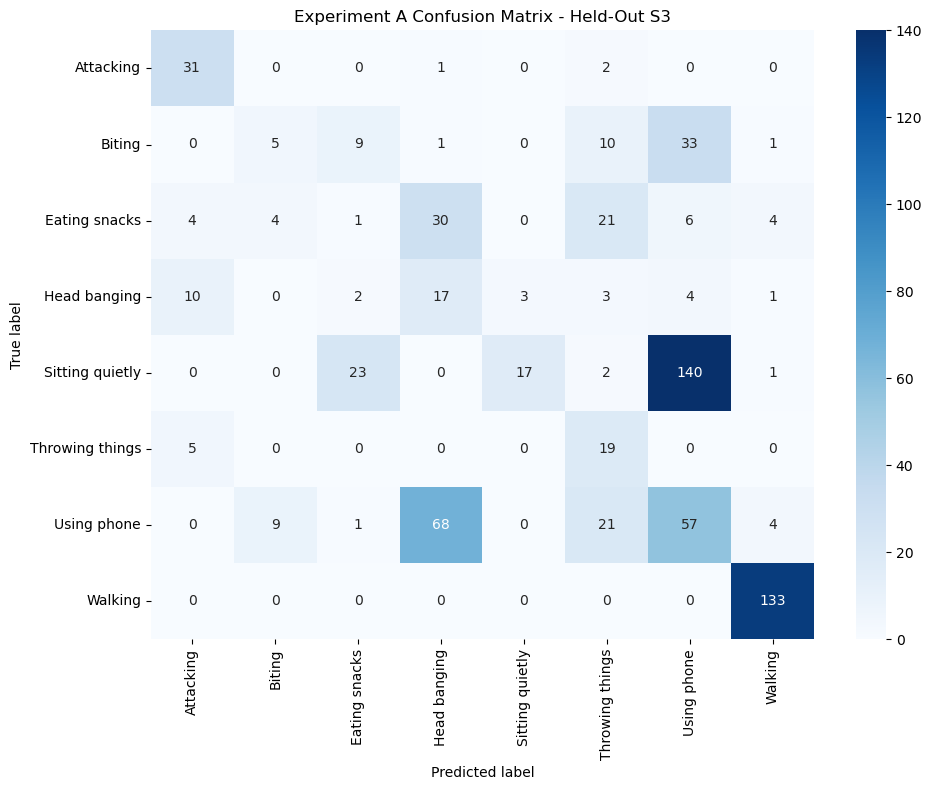

In [9]:
a_s3 = run_loso_fold(windows_a, held_out_subject=3, random_state=RANDOM_STATE)
a_s3.confusion.to_csv(ARTIFACT_DIR / 'a_confusion_subject_3.csv')
show_fold(a_s3, 'Experiment A Confusion Matrix - Held-Out S3')

### Experiment A - Held-Out S5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,3317,471,0.583864,0.588399,0.683983,0.692982,0.675214


,precision,recall,f1-score,support
Attacking,0.966667,1.000000,0.983051,29.000000
Biting,0.000000,0.000000,0.000000,38.000000
Eating snacks,0.366935,0.968085,0.532164,94.000000
Head banging,1.000000,1.000000,1.000000,25.000000
Sitting quietly,0.800000,0.122449,0.212389,98.000000
Throwing things,1.000000,0.960000,0.979592,25.000000
Using phone,0.000000,0.000000,0.000000,68.000000
Walking,1.000000,1.000000,1.000000,94.000000
accuracy,0.583864,0.583864,0.583864,0.583864
macro avg,0.641700,0.631317,0.588399,471.000000


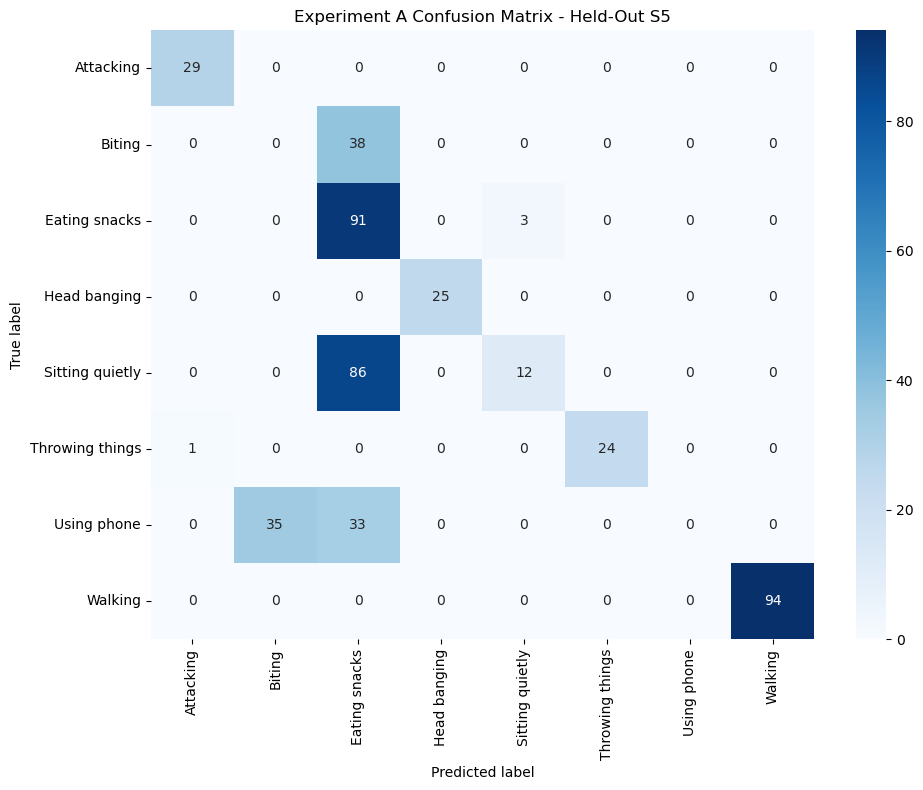

In [10]:
a_s5 = run_loso_fold(windows_a, held_out_subject=5, random_state=RANDOM_STATE)
a_s5.confusion.to_csv(ARTIFACT_DIR / 'a_confusion_subject_5.csv')
show_fold(a_s5, 'Experiment A Confusion Matrix - Held-Out S5')

In [11]:
result_a = combine_loso_folds([a_s1, a_s2, a_s3, a_s5])
result_a.fold_metrics.to_csv(ARTIFACT_DIR / 'a_fold_metrics.csv', index=False)
display(result_a.fold_metrics)
display(pd.DataFrame([summarize_experiment('A', result_a)]))
display(top_confusions(result_a))

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.545643,0.476734,0.663594,0.742268,0.600000
1,2,3317,472,0.620763,0.502038,0.693182,0.897059,0.564815
2,3,2853,703,0.398293,0.361090,0.495238,0.395437,0.662420
3,5,3317,471,0.583864,0.588399,0.683983,0.692982,0.675214


,experiment,mean_fold_accuracy,pooled_accuracy,pooled_macro_f1,pooled_abnormal_f1,worst_subject,worst_subject_accuracy
0,A,0.537141,0.522086,0.481934,0.605364,3,0.398293


,true_label,predicted_label,windows
25,Sitting quietly,Eating snacks,157
27,Sitting quietly,Using phone,142
37,Using phone,Sitting quietly,118
6,Biting,Eating snacks,78
36,Using phone,Head banging,72
34,Using phone,Biting,45
9,Biting,Using phone,45
14,Eating snacks,Sitting quietly,37
35,Using phone,Eating snacks,35
16,Eating snacks,Using phone,34


## 5. Experiment B: Add V7 Handcrafted Signals

### Experiment B - Held-Out S1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.526971,0.447226,0.624161,0.522472,0.775


,precision,recall,f1-score,support
Attacking,0.333333,0.137931,0.195122,29.000000
Biting,1.000000,0.527778,0.690909,36.000000
Eating snacks,0.556291,0.857143,0.674699,98.000000
Head banging,0.224299,0.960000,0.363636,25.000000
Sitting quietly,0.027778,0.010526,0.015267,95.000000
Throwing things,0.500000,0.666667,0.571429,30.000000
Using phone,0.625000,0.069444,0.125000,72.000000
Walking,0.889908,1.000000,0.941748,97.000000
accuracy,0.526971,0.526971,0.526971,0.526971
macro avg,0.519576,0.528686,0.447226,482.000000


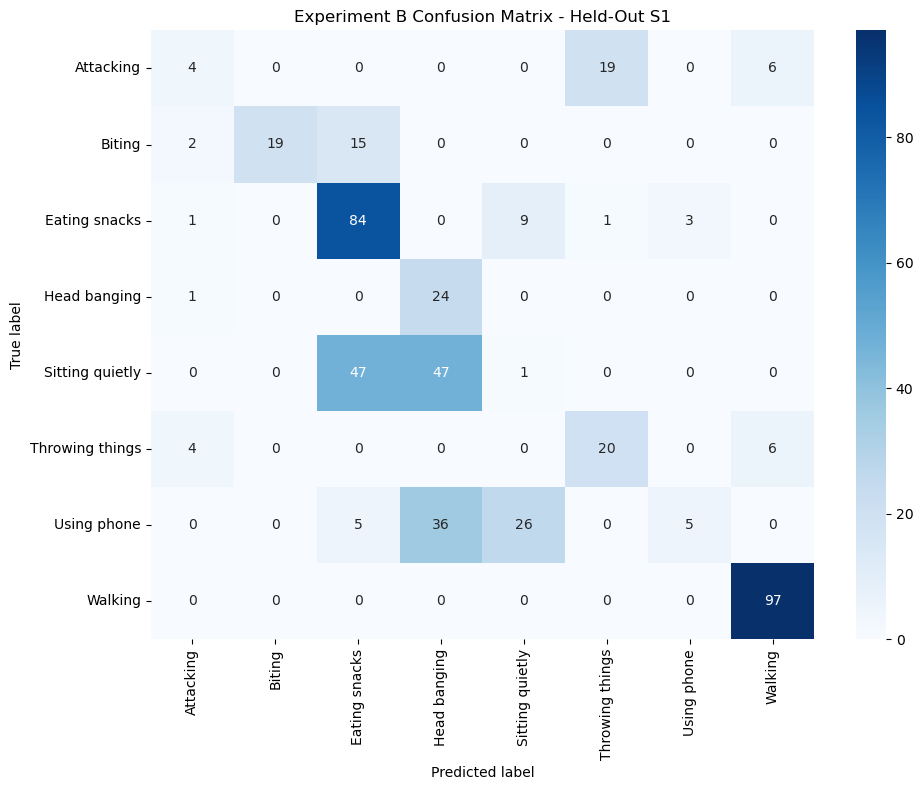

In [12]:
b_s1 = run_loso_fold(windows_b, held_out_subject=1, random_state=RANDOM_STATE)
b_s1.confusion.to_csv(ARTIFACT_DIR / 'b_confusion_subject_1.csv')
show_fold(b_s1, 'Experiment B Confusion Matrix - Held-Out S1')

### Experiment B - Held-Out S2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,3317,472,0.722458,0.648449,0.810526,0.939024,0.712963


,precision,recall,f1-score,support
Attacking,0.600000,0.078947,0.139535,38.000000
Biting,0.857143,1.000000,0.923077,18.000000
Eating snacks,0.732759,0.876289,0.798122,97.000000
Head banging,0.928571,1.000000,0.962963,26.000000
Sitting quietly,0.551724,0.979592,0.705882,98.000000
Throwing things,0.571429,0.615385,0.592593,26.000000
Using phone,0.500000,0.041096,0.075949,73.000000
Walking,1.000000,0.979167,0.989474,96.000000
accuracy,0.722458,0.722458,0.722458,0.722458
macro avg,0.717703,0.696309,0.648449,472.000000


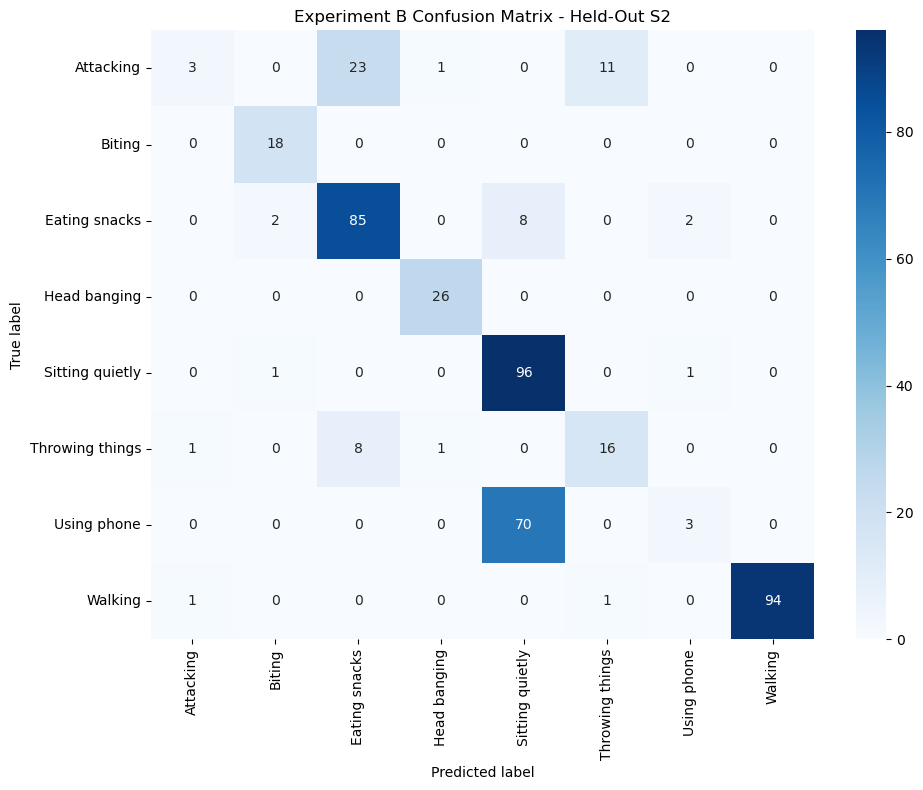

In [13]:
b_s2 = run_loso_fold(windows_b, held_out_subject=2, random_state=RANDOM_STATE)
b_s2.confusion.to_csv(ARTIFACT_DIR / 'b_confusion_subject_2.csv')
show_fold(b_s2, 'Experiment B Confusion Matrix - Held-Out S2')

### Experiment B - Held-Out S3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,2853,703,0.406828,0.39558,0.516854,0.399306,0.732484


,precision,recall,f1-score,support
Attacking,0.412500,0.970588,0.578947,34.000000
Biting,0.262295,0.271186,0.266667,59.000000
Eating snacks,0.142857,0.100000,0.117647,70.000000
Head banging,0.160377,0.425000,0.232877,40.000000
Sitting quietly,1.000000,0.071038,0.132653,183.000000
Throwing things,0.463415,0.791667,0.584615,24.000000
Using phone,0.244444,0.343750,0.285714,160.000000
Walking,0.984375,0.947368,0.965517,133.000000
accuracy,0.406828,0.406828,0.406828,0.406828
macro avg,0.458783,0.490075,0.395580,703.000000


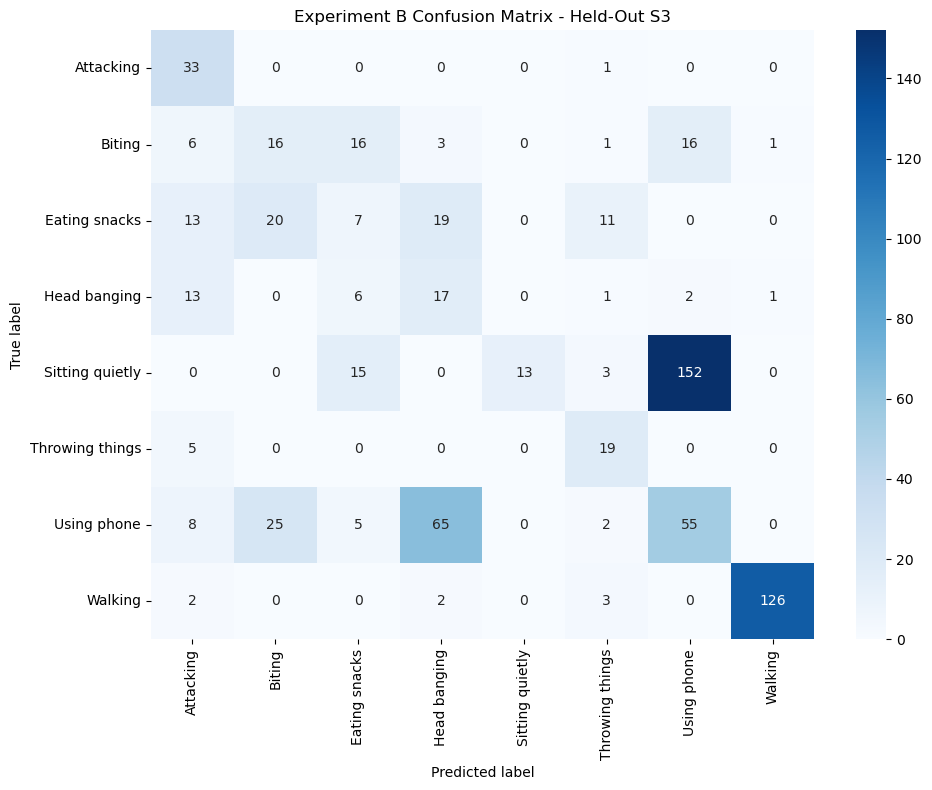

In [14]:
b_s3 = run_loso_fold(windows_b, held_out_subject=3, random_state=RANDOM_STATE)
b_s3.confusion.to_csv(ARTIFACT_DIR / 'b_confusion_subject_3.csv')
show_fold(b_s3, 'Experiment B Confusion Matrix - Held-Out S3')

### Experiment B - Held-Out S5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,3317,471,0.66879,0.718204,0.987124,0.991379,0.982906


,precision,recall,f1-score,support
Attacking,1.000000,0.965517,0.982456,29.00000
Biting,0.972973,0.947368,0.960000,38.00000
Eating snacks,0.439024,0.957447,0.602007,94.00000
Head banging,1.000000,1.000000,1.000000,25.00000
Sitting quietly,0.303571,0.173469,0.220779,98.00000
Throwing things,0.961538,1.000000,0.980392,25.00000
Using phone,0.000000,0.000000,0.000000,68.00000
Walking,1.000000,1.000000,1.000000,94.00000
accuracy,0.668790,0.668790,0.668790,0.66879
macro avg,0.709638,0.755475,0.718204,471.00000


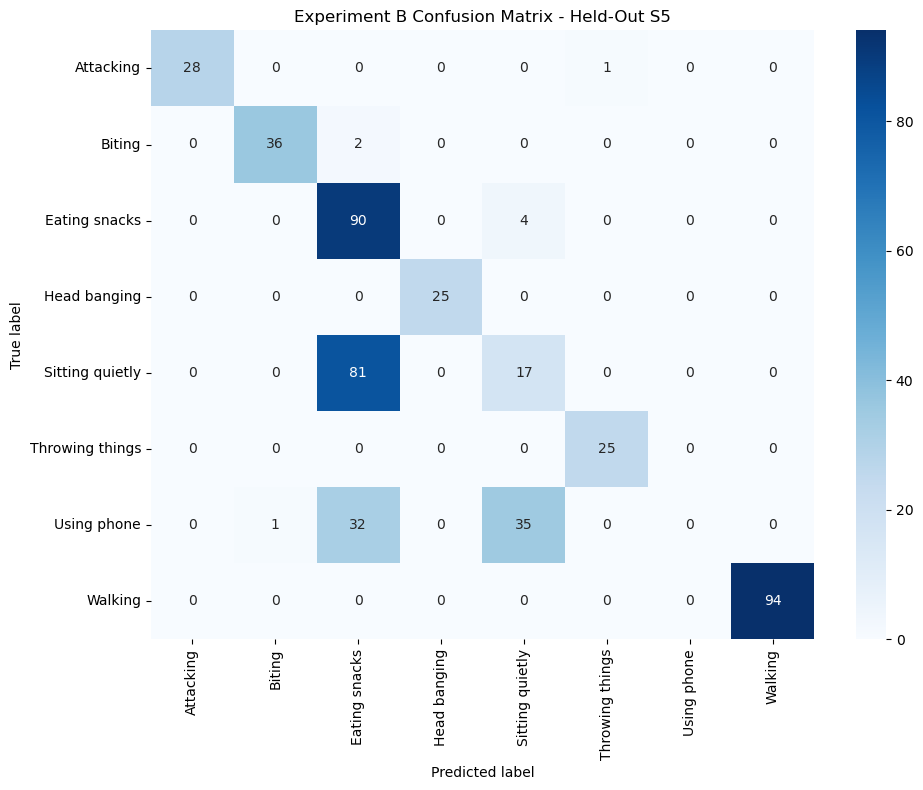

In [15]:
b_s5 = run_loso_fold(windows_b, held_out_subject=5, random_state=RANDOM_STATE)
b_s5.confusion.to_csv(ARTIFACT_DIR / 'b_confusion_subject_5.csv')
show_fold(b_s5, 'Experiment B Confusion Matrix - Held-Out S5')

In [16]:
result_b = combine_loso_folds([b_s1, b_s2, b_s3, b_s5])
result_b.fold_metrics.to_csv(ARTIFACT_DIR / 'b_fold_metrics.csv', index=False)
display(result_b.fold_metrics)
display(pd.DataFrame([summarize_experiment('B', result_b)]))
display(top_confusions(result_b))

ab_subject_delta = result_a.fold_metrics[['held_out_subject', 'accuracy', 'macro_f1', 'abnormal_f1']].merge(
    result_b.fold_metrics[['held_out_subject', 'accuracy', 'macro_f1', 'abnormal_f1']],
    on='held_out_subject', suffixes=('_a', '_b')
)
for metric in ['accuracy', 'macro_f1', 'abnormal_f1']:
    ab_subject_delta[f'{metric}_delta_b_minus_a'] = ab_subject_delta[f'{metric}_b'] - ab_subject_delta[f'{metric}_a']
display(ab_subject_delta)

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.526971,0.447226,0.624161,0.522472,0.775000
1,2,3317,472,0.722458,0.648449,0.810526,0.939024,0.712963
2,3,2853,703,0.406828,0.395580,0.516854,0.399306,0.732484
3,5,3317,471,0.668790,0.718204,0.987124,0.991379,0.982906


,experiment,mean_fold_accuracy,pooled_accuracy,pooled_macro_f1,pooled_abnormal_f1,worst_subject,worst_subject_accuracy
0,B,0.581262,0.56203,0.552265,0.686106,3,0.406828


,true_label,predicted_label,windows
25,Sitting quietly,Using phone,153
22,Sitting quietly,Eating snacks,143
34,Using phone,Sitting quietly,131
33,Using phone,Head banging,101
23,Sitting quietly,Head banging,47
32,Using phone,Eating snacks,42
5,Biting,Eating snacks,33
2,Attacking,Throwing things,32
31,Using phone,Biting,26
0,Attacking,Eating snacks,23


,held_out_subject,accuracy_a,macro_f1_a,abnormal_f1_a,accuracy_b,macro_f1_b,abnormal_f1_b,accuracy_delta_b_minus_a,macro_f1_delta_b_minus_a,abnormal_f1_delta_b_minus_a
0,1,0.545643,0.476734,0.663594,0.526971,0.447226,0.624161,-0.018672,-0.029508,-0.039433
1,2,0.620763,0.502038,0.693182,0.722458,0.648449,0.810526,0.101695,0.146411,0.117344
2,3,0.398293,0.361090,0.495238,0.406828,0.395580,0.516854,0.008535,0.034490,0.021616
3,5,0.583864,0.588399,0.683983,0.668790,0.718204,0.987124,0.084926,0.129805,0.303142


## 6. Hard-Subject Analysis Before Experiment C

Experiment C is targeted at cross-subject instability and hand-activity confusion. It adds participant-local robust smoothing/scale, symmetric hand features, and spectral summaries while preserving the same labels, windows, folds, classifier, and seed.

In [17]:
hard_subjects_ab = pd.DataFrame([
    summarize_experiment('A', result_a),
    summarize_experiment('B', result_b),
])
display(hard_subjects_ab[['experiment', 'worst_subject', 'worst_subject_accuracy', 'pooled_abnormal_f1', 'pooled_macro_f1']])
print('Experiment A top confusions:')
display(top_confusions(result_a))
print('Experiment B top confusions:')
display(top_confusions(result_b))

,experiment,worst_subject,worst_subject_accuracy,pooled_abnormal_f1,pooled_macro_f1
0,A,3,0.398293,0.605364,0.481934
1,B,3,0.406828,0.686106,0.552265


Experiment A top confusions:


,true_label,predicted_label,windows
25,Sitting quietly,Eating snacks,157
27,Sitting quietly,Using phone,142
37,Using phone,Sitting quietly,118
6,Biting,Eating snacks,78
36,Using phone,Head banging,72
34,Using phone,Biting,45
9,Biting,Using phone,45
14,Eating snacks,Sitting quietly,37
35,Using phone,Eating snacks,35
16,Eating snacks,Using phone,34


Experiment B top confusions:


,true_label,predicted_label,windows
25,Sitting quietly,Using phone,153
22,Sitting quietly,Eating snacks,143
34,Using phone,Sitting quietly,131
33,Using phone,Head banging,101
23,Sitting quietly,Head banging,47
32,Using phone,Eating snacks,42
5,Biting,Eating snacks,33
2,Attacking,Throwing things,32
31,Using phone,Biting,26
0,Attacking,Eating snacks,23


## 7. Experiment C: Targeted Robust and Spectral Upgrade

In [18]:
windows_c = {}
for subject, path in training_files.items():
    print(f'Experiment C: loading/extracting subject {subject}', flush=True)
    windows_c[subject] = load_or_extract_experiment_subject(path, subject, 'C', CACHE_DIR)
print('Experiment C shapes:', {s: w.x.shape for s, w in windows_c.items()})

Experiment C: loading/extracting subject 1


Experiment C: loading/extracting subject 2


Experiment C: loading/extracting subject 3


Experiment C: loading/extracting subject 5


Experiment C shapes: {1: (963, 2635), 2: (945, 2635), 3: (1409, 2635), 5: (945, 2635)}


### Experiment C - Held-Out S1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.560166,0.499857,0.79602,0.987654,0.666667


,precision,recall,f1-score,support
Attacking,0.400000,0.137931,0.205128,29.000000
Biting,1.000000,0.055556,0.105263,36.000000
Eating snacks,0.493827,0.816327,0.615385,98.000000
Head banging,1.000000,0.880000,0.936170,25.000000
Sitting quietly,0.022727,0.010526,0.014388,95.000000
Throwing things,0.574468,0.900000,0.701299,30.000000
Using phone,0.402174,0.513889,0.451220,72.000000
Walking,0.941748,1.000000,0.970000,97.000000
accuracy,0.560166,0.560166,0.560166,0.560166
macro avg,0.604368,0.539279,0.499857,482.000000


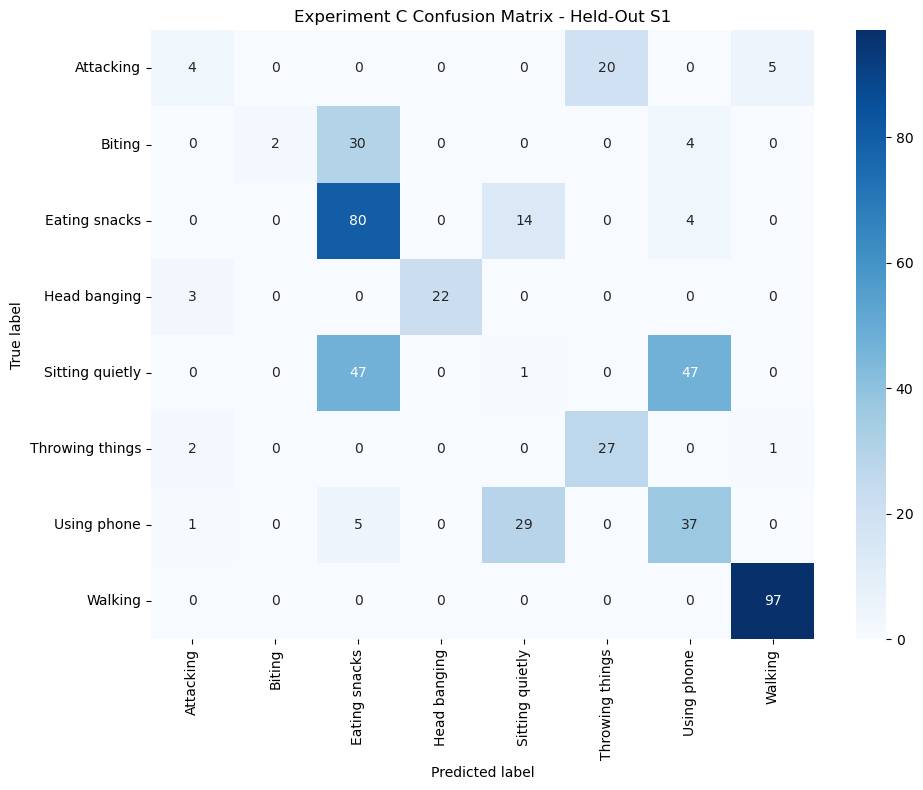

In [19]:
c_s1 = run_loso_fold(windows_c, held_out_subject=1, random_state=RANDOM_STATE)
c_s1.confusion.to_csv(ARTIFACT_DIR / 'c_confusion_subject_1.csv')
show_fold(c_s1, 'Experiment C Confusion Matrix - Held-Out S1')

### Experiment C - Held-Out S2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,3317,472,0.713983,0.633178,0.78534,0.903614,0.694444


,precision,recall,f1-score,support
Attacking,0.714286,0.131579,0.222222,38.000000
Biting,0.720000,1.000000,0.837209,18.000000
Eating snacks,0.711864,0.865979,0.781395,97.000000
Head banging,0.928571,1.000000,0.962963,26.000000
Sitting quietly,0.545455,0.979592,0.700730,98.000000
Throwing things,0.608696,0.538462,0.571429,26.000000
Using phone,0.000000,0.000000,0.000000,73.000000
Walking,1.000000,0.979167,0.989474,96.000000
accuracy,0.713983,0.713983,0.713983,0.713983
macro avg,0.653609,0.686847,0.633178,472.000000


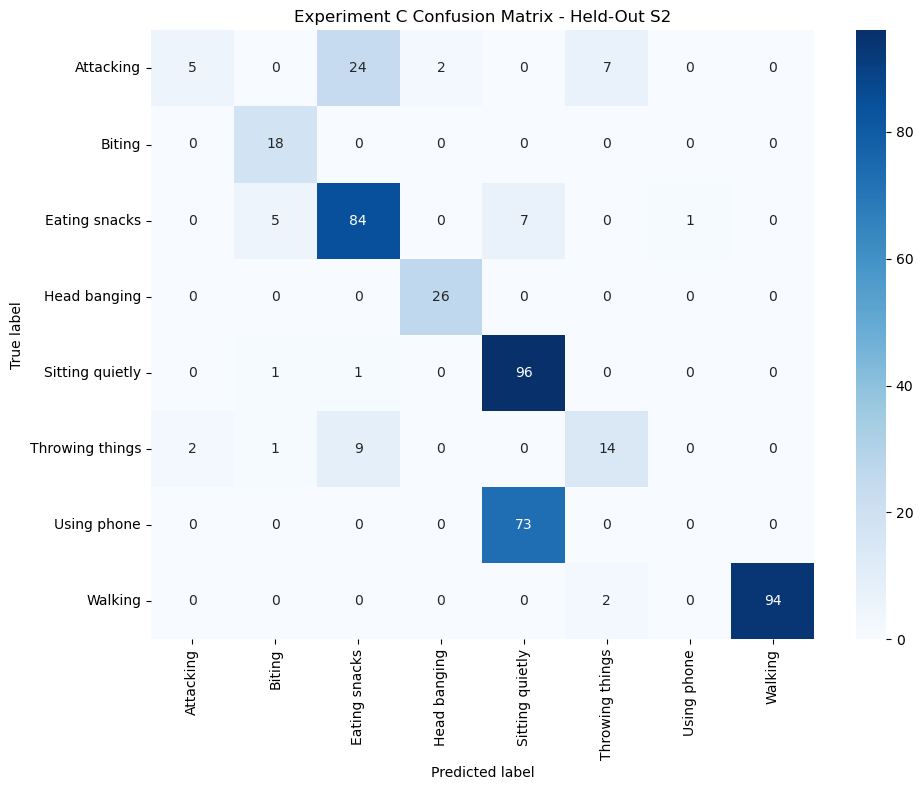

In [20]:
c_s2 = run_loso_fold(windows_c, held_out_subject=2, random_state=RANDOM_STATE)
c_s2.confusion.to_csv(ARTIFACT_DIR / 'c_confusion_subject_2.csv')
show_fold(c_s2, 'Experiment C Confusion Matrix - Held-Out S2')

### Experiment C - Held-Out S3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,2853,703,0.41963,0.396967,0.514806,0.400709,0.719745


,precision,recall,f1-score,support
Attacking,0.384615,0.882353,0.535714,34.00000
Biting,0.186667,0.237288,0.208955,59.00000
Eating snacks,0.212121,0.100000,0.135922,70.00000
Head banging,0.246753,0.475000,0.324786,40.00000
Sitting quietly,0.818182,0.098361,0.175610,183.00000
Throwing things,0.384615,0.833333,0.526316,24.00000
Using phone,0.251064,0.368750,0.298734,160.00000
Walking,0.977099,0.962406,0.969697,133.00000
accuracy,0.419630,0.419630,0.419630,0.41963
macro avg,0.432640,0.494686,0.396967,703.00000


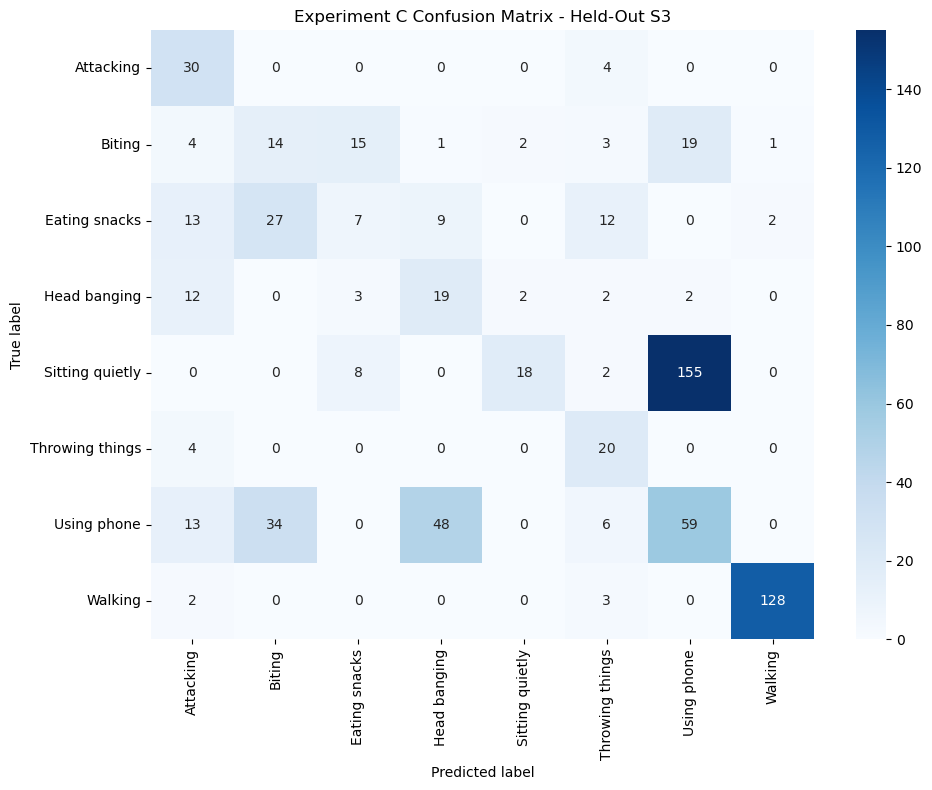

In [21]:
c_s3 = run_loso_fold(windows_c, held_out_subject=3, random_state=RANDOM_STATE)
c_s3.confusion.to_csv(ARTIFACT_DIR / 'c_confusion_subject_3.csv')
show_fold(c_s3, 'Experiment C Confusion Matrix - Held-Out S3')

### Experiment C - Held-Out S5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,3317,471,0.609342,0.648697,0.897196,0.989691,0.820513


,precision,recall,f1-score,support
Attacking,1.000000,0.965517,0.982456,29.000000
Biting,0.944444,0.447368,0.607143,38.000000
Eating snacks,0.390041,1.000000,0.561194,94.000000
Head banging,1.000000,1.000000,1.000000,25.000000
Sitting quietly,0.102564,0.040816,0.058394,98.000000
Throwing things,0.961538,1.000000,0.980392,25.000000
Using phone,0.000000,0.000000,0.000000,68.000000
Walking,1.000000,1.000000,1.000000,94.000000
accuracy,0.609342,0.609342,0.609342,0.609342
macro avg,0.674824,0.681713,0.648697,471.000000


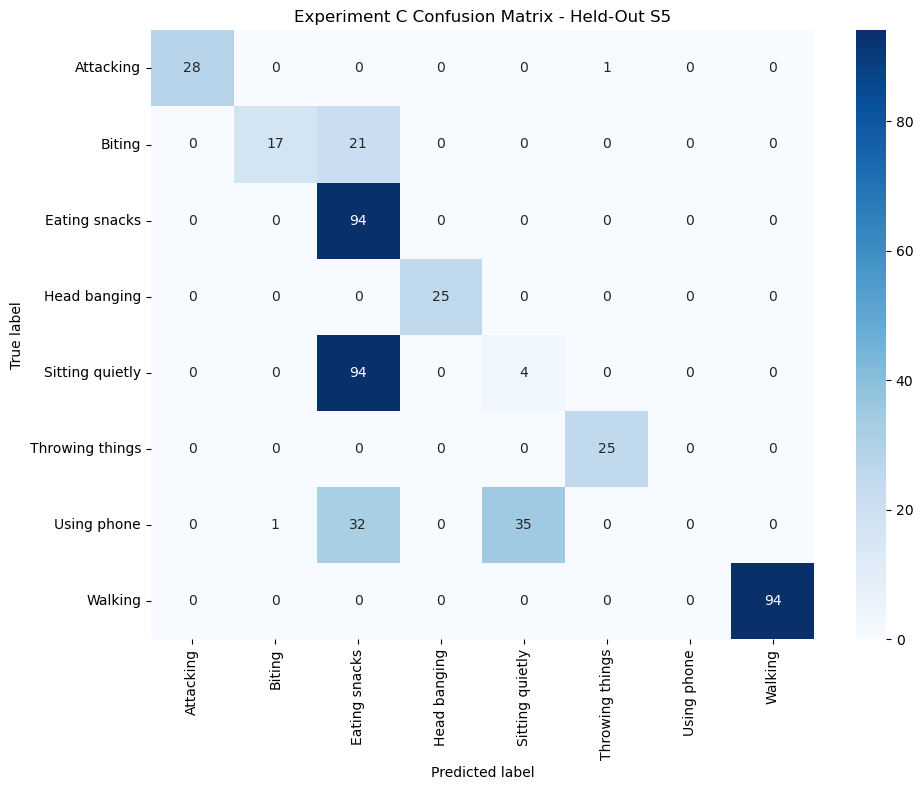

In [22]:
c_s5 = run_loso_fold(windows_c, held_out_subject=5, random_state=RANDOM_STATE)
c_s5.confusion.to_csv(ARTIFACT_DIR / 'c_confusion_subject_5.csv')
show_fold(c_s5, 'Experiment C Confusion Matrix - Held-Out S5')

In [23]:
result_c = combine_loso_folds([c_s1, c_s2, c_s3, c_s5])
result_c.fold_metrics.to_csv(ARTIFACT_DIR / 'c_fold_metrics.csv', index=False)
display(result_c.fold_metrics)
display(pd.DataFrame([summarize_experiment('C', result_c)]))
display(top_confusions(result_c))

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.560166,0.499857,0.796020,0.987654,0.666667
1,2,3317,472,0.713983,0.633178,0.785340,0.903614,0.694444
2,3,2853,703,0.419630,0.396967,0.514806,0.400709,0.719745
3,5,3317,471,0.609342,0.648697,0.897196,0.989691,0.820513


,experiment,mean_fold_accuracy,pooled_accuracy,pooled_macro_f1,pooled_abnormal_f1,worst_subject,worst_subject_accuracy
0,C,0.57578,0.558741,0.552883,0.696651,3,0.41963


,true_label,predicted_label,windows
26,Sitting quietly,Using phone,202
24,Sitting quietly,Eating snacks,150
35,Using phone,Sitting quietly,137
5,Biting,Eating snacks,66
34,Using phone,Head banging,48
33,Using phone,Eating snacks,37
32,Using phone,Biting,35
12,Eating snacks,Biting,32
2,Attacking,Throwing things,32
0,Attacking,Eating snacks,24


## 8. Controlled A/B/C Comparison and Model Lock

In [24]:
comparison = pd.DataFrame([
    summarize_experiment('A', result_a),
    summarize_experiment('B', result_b),
    summarize_experiment('C', result_c),
])
comparison.to_csv(ARTIFACT_DIR / 'abc_summary.csv', index=False)
selected_experiment = select_winning_experiment(comparison)
(ARTIFACT_DIR / 'selected_experiment.json').write_text(
    json.dumps({'selected_experiment': selected_experiment, 'selection_order': ['pooled_abnormal_f1', 'worst_subject_accuracy', 'pooled_macro_f1']}, indent=2),
    encoding='utf-8'
)
display(comparison)
print('Locked experiment before S4 ground truth:', selected_experiment)

fold_comparison = result_a.fold_metrics[['held_out_subject', 'accuracy']].rename(columns={'accuracy': 'accuracy_a'})
fold_comparison = fold_comparison.merge(result_b.fold_metrics[['held_out_subject', 'accuracy']].rename(columns={'accuracy': 'accuracy_b'}), on='held_out_subject')
fold_comparison = fold_comparison.merge(result_c.fold_metrics[['held_out_subject', 'accuracy']].rename(columns={'accuracy': 'accuracy_c'}), on='held_out_subject')
fold_comparison['delta_b_minus_a'] = fold_comparison['accuracy_b'] - fold_comparison['accuracy_a']
fold_comparison['delta_c_minus_b'] = fold_comparison['accuracy_c'] - fold_comparison['accuracy_b']
fold_comparison.to_csv(ARTIFACT_DIR / 'abc_subject_accuracy_deltas.csv', index=False)
display(fold_comparison)

,experiment,mean_fold_accuracy,pooled_accuracy,pooled_macro_f1,pooled_abnormal_f1,worst_subject,worst_subject_accuracy
0,A,0.537141,0.522086,0.481934,0.605364,3,0.398293
1,B,0.581262,0.562030,0.552265,0.686106,3,0.406828
2,C,0.575780,0.558741,0.552883,0.696651,3,0.419630


Locked experiment before S4 ground truth: C


,held_out_subject,accuracy_a,accuracy_b,accuracy_c,delta_b_minus_a,delta_c_minus_b
0,1,0.545643,0.526971,0.560166,-0.018672,0.033195
1,2,0.620763,0.722458,0.713983,0.101695,-0.008475
2,3,0.398293,0.406828,0.419630,0.008535,0.012802
3,5,0.583864,0.668790,0.609342,0.084926,-0.059448


## 9. Fit the Locked Four-Subject Model

In [25]:
windows_by_experiment = {'A': windows_a, 'B': windows_b, 'C': windows_c}
results_by_experiment = {'A': result_a, 'B': result_b, 'C': result_c}
selected_windows = windows_by_experiment[selected_experiment]
selected_result = results_by_experiment[selected_experiment]
all_stage1_windows = concatenate_window_features([selected_windows[s] for s in SUBJECTS_STAGE1])
locked_model = fit_estimator(all_stage1_windows, random_state=RANDOM_STATE)
locked_artifact = build_experiment_artifact(
    locked_model,
    all_stage1_windows.x.columns,
    selected_experiment,
    metadata={
        'training_subjects': SUBJECTS_STAGE1,
        'n_training_windows': len(all_stage1_windows.y),
        'selection_summary': comparison.to_dict('records'),
        'loso_summary': selected_result.summary,
    },
)
LOCKED_MODEL_PATH = ARTIFACT_DIR / f'locked_experiment_{selected_experiment.lower()}_subjects_1_2_3_5.joblib'
save_experiment_artifact(LOCKED_MODEL_PATH, locked_artifact)
locked_artifact = load_experiment_artifact(LOCKED_MODEL_PATH)
print('Locked artifact:', LOCKED_MODEL_PATH.resolve())

Locked artifact: .\artifacts\abc_ablation\locked_experiment_c_subjects_1_2_3_5.joblib


## 10. S4 Prediction After Model Lock

In [26]:
s4_shared = pd.read_csv(S4_SHARED_FILE)
s4_prediction = predict_experiment_frame_labels(s4_shared, locked_artifact, participant_id=4)
s4_output_paths = write_prediction_outputs(OUTPUT_DIR, s4_shared, s4_prediction, participant_id=4)
display(pd.Series(s4_prediction.frame_labels).value_counts().rename('frames').to_frame())
print('Filled S4 CSV:', s4_output_paths.filled.resolve())
print('S4 submission CSV:', s4_output_paths.submission.resolve())

,frames
Using phone,30171
Walking,20550
Sitting quietly,18750
Eating snacks,16350
Biting,13800
Head banging,6600
Attacking,6000
Throwing things,5700


Filled S4 CSV: .\outputs\abc_ablation\test_data_keypoint_shared_predicted.csv
S4 submission CSV: .\outputs\abc_ablation\submission_tsfel_histgb.csv


## 11. Load S4 Ground Truth and Evaluate the Locked Model

,value
accuracy,0.782993
macro_f1,0.821328
abnormal_f1,0.859528
abnormal_precision,0.770455
abnormal_recall,0.971888
error_rate,0.217007


,precision,recall,f1-score,support
Attacking,0.867925,0.951724,0.907895,4350.000000
Biting,0.599562,0.968198,0.740541,8490.000000
Eating snacks,0.857143,0.708134,0.775546,18810.000000
Head banging,0.989529,0.964286,0.976744,5880.000000
Sitting quietly,0.843333,0.632500,0.722857,24000.000000
Throwing things,0.805617,0.886179,0.843980,3690.000000
Using phone,0.585956,0.679513,0.629276,23430.000000
Walking,0.981873,0.965825,0.973783,20190.000000
accuracy,0.782993,0.782993,0.782993,0.782993
macro avg,0.816367,0.844545,0.821328,108840.000000


,true_label,predicted_label,count
15,Sitting quietly,Using phone,8460
18,Using phone,Biting,3600
9,Eating snacks,Using phone,2790
20,Using phone,Sitting quietly,2190
19,Using phone,Eating snacks,1650
6,Eating snacks,Biting,1650
7,Eating snacks,Sitting quietly,600
14,Sitting quietly,Eating snacks,330
8,Eating snacks,Throwing things,300
22,Walking,Attacking,300


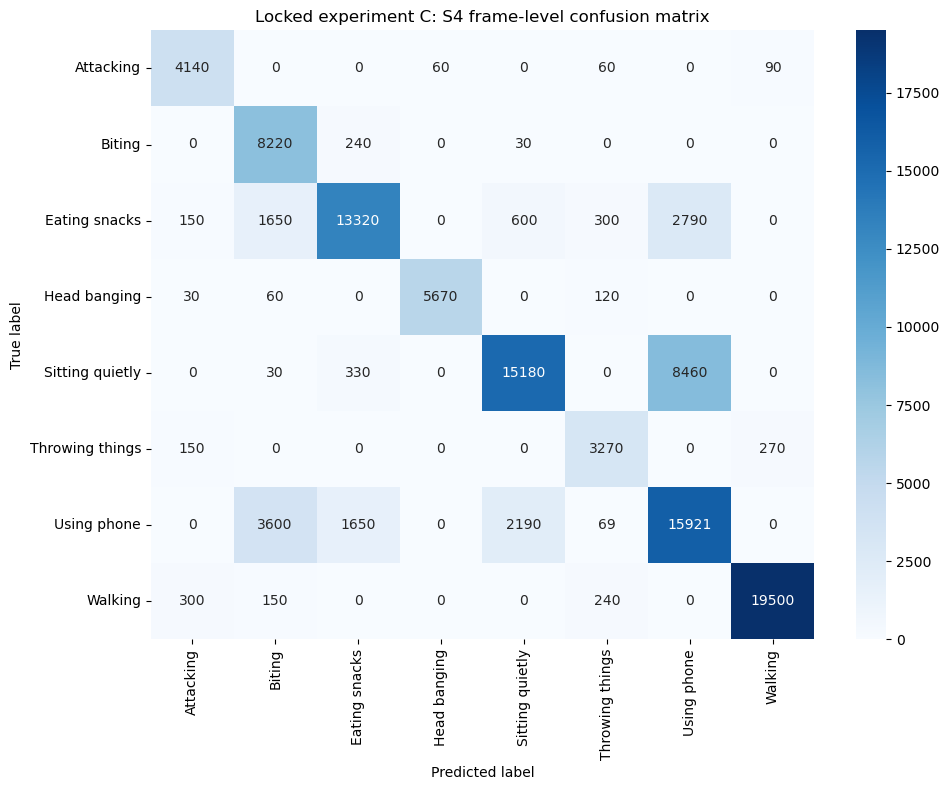

In [27]:
s4_labeled = pd.read_csv(S4_LABEL_FILE)
assert s4_labeled[['frame_id', *COORD_COLUMNS]].equals(s4_shared[['frame_id', *COORD_COLUMNS]])
s4_truth = clean_labels(s4_labeled['Action Label'])
valid_s4 = s4_truth.isin(CLASSES)
s4_evaluation = evaluate_predictions(s4_truth[valid_s4], s4_prediction.frame_labels[valid_s4.to_numpy()])
s4_metrics = {k: v for k, v in s4_evaluation.items() if k != 'classification_report'}
s4_metrics['error_rate'] = 1.0 - s4_metrics['accuracy']
(ARTIFACT_DIR / 'locked_model_s4_metrics.json').write_text(json.dumps(s4_metrics, indent=2), encoding='utf-8')
pd.DataFrame(s4_evaluation['classification_report']).transpose().to_csv(
    ARTIFACT_DIR / 'locked_model_s4_classification_report.csv'
)
s4_confusion = pd.DataFrame(
    confusion_matrix(
        s4_truth[valid_s4],
        s4_prediction.frame_labels[valid_s4.to_numpy()],
        labels=CLASSES,
    ),
    index=CLASSES,
    columns=CLASSES,
)
s4_confusion.to_csv(ARTIFACT_DIR / 'locked_model_s4_confusion.csv')
s4_confusion_pairs = []
for true_label in CLASSES:
    for predicted_label in CLASSES:
        if true_label != predicted_label and s4_confusion.loc[true_label, predicted_label] > 0:
            s4_confusion_pairs.append({
                'true_label': true_label,
                'predicted_label': predicted_label,
                'count': int(s4_confusion.loc[true_label, predicted_label]),
            })
s4_top_confusions = pd.DataFrame(s4_confusion_pairs).sort_values('count', ascending=False).head(15)
s4_top_confusions.to_csv(ARTIFACT_DIR / 'locked_model_s4_top_confusions.csv', index=False)
display(pd.Series(s4_metrics, name='value').to_frame())
display(pd.DataFrame(s4_evaluation['classification_report']).transpose())
display(s4_top_confusions)
plt.figure(figsize=(10, 8))
sns.heatmap(s4_confusion, annot=True, fmt='d', cmap='Blues')
plt.title(f'Locked experiment {selected_experiment}: S4 frame-level confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## 12. Five-Subject LOSO with the Locked Experiment

In [28]:
s4_selected_windows = load_or_extract_experiment_subject(
    S4_LABEL_FILE, 4, selected_experiment, CACHE_DIR
)
five_subject_windows = {**selected_windows, 4: s4_selected_windows}
print('Five-subject feature shapes:', {s: w.x.shape for s, w in sorted(five_subject_windows.items())})

Five-subject feature shapes: {1: (963, 2635), 2: (945, 2635), 3: (1409, 2635), 4: (1433, 2635), 5: (945, 2635)}


### Locked Five-Subject LOSO - Held-Out S1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,4732,482,0.53112,0.445423,0.639731,0.536723,0.791667


,precision,recall,f1-score,support
Attacking,0.600000,0.103448,0.176471,29.00000
Biting,1.000000,0.472222,0.641509,36.00000
Eating snacks,0.477011,0.846939,0.610294,98.00000
Head banging,0.233645,1.000000,0.378788,25.00000
Sitting quietly,0.045455,0.010526,0.017094,95.00000
Throwing things,0.562500,0.900000,0.692308,30.00000
Using phone,0.500000,0.041667,0.076923,72.00000
Walking,0.941748,1.000000,0.970000,97.00000
accuracy,0.531120,0.531120,0.531120,0.53112
macro avg,0.545045,0.546850,0.445423,482.00000


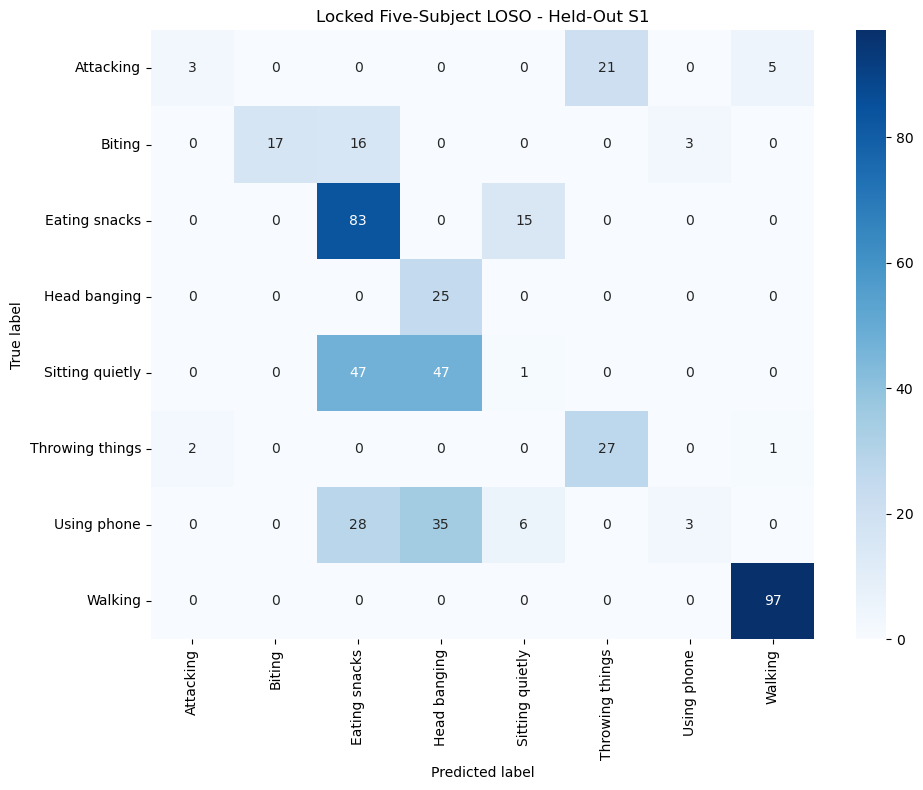

In [29]:
final_s1 = run_loso_fold(five_subject_windows, held_out_subject=1, random_state=RANDOM_STATE)
final_s1.confusion.to_csv(ARTIFACT_DIR / 'final_loso5_confusion_subject_1.csv')
show_fold(final_s1, 'Locked Five-Subject LOSO - Held-Out S1')

### Locked Five-Subject LOSO - Held-Out S2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,4750,472,0.733051,0.680149,0.80597,0.870968,0.75


,precision,recall,f1-score,support
Attacking,1.000000,0.447368,0.618182,38.000000
Biting,0.600000,1.000000,0.750000,18.000000
Eating snacks,0.738318,0.814433,0.774510,97.000000
Head banging,0.838710,1.000000,0.912281,26.000000
Sitting quietly,0.548571,0.979592,0.703297,98.000000
Throwing things,0.933333,0.538462,0.682927,26.000000
Using phone,0.000000,0.000000,0.000000,73.000000
Walking,1.000000,1.000000,1.000000,96.000000
accuracy,0.733051,0.733051,0.733051,0.733051
macro avg,0.707367,0.722482,0.680149,472.000000


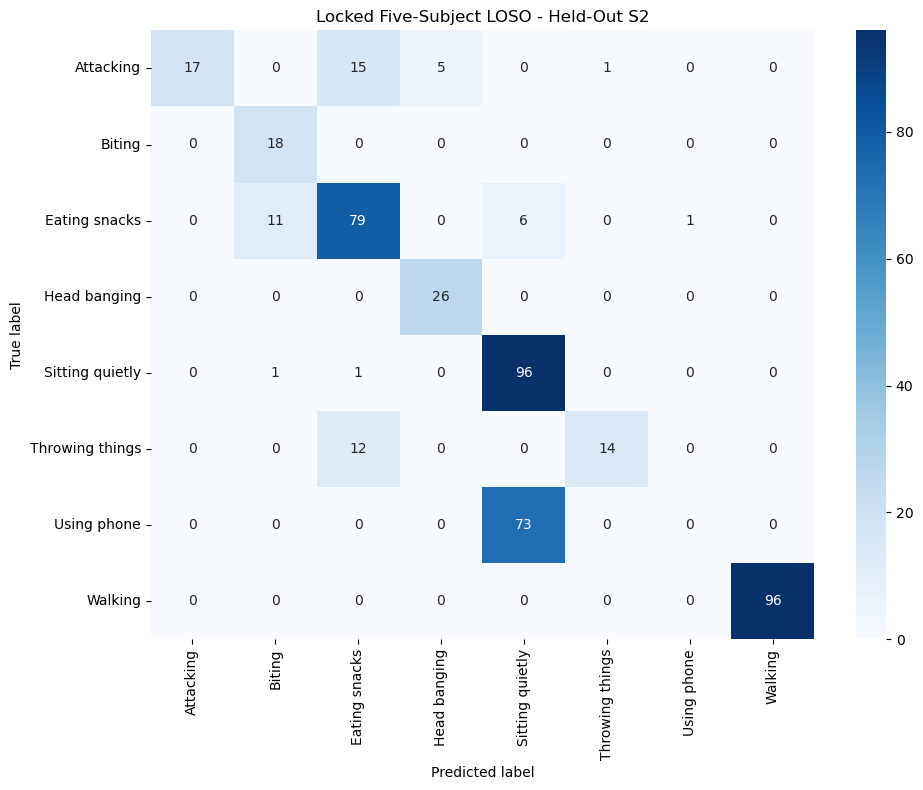

In [30]:
final_s2 = run_loso_fold(five_subject_windows, held_out_subject=2, random_state=RANDOM_STATE)
final_s2.confusion.to_csv(ARTIFACT_DIR / 'final_loso5_confusion_subject_2.csv')
show_fold(final_s2, 'Locked Five-Subject LOSO - Held-Out S2')

### Locked Five-Subject LOSO - Held-Out S3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,4286,703,0.762447,0.784016,0.877551,0.941606,0.821656


,precision,recall,f1-score,support
Attacking,0.825000,0.970588,0.891892,34.000000
Biting,0.950000,0.644068,0.767677,59.000000
Eating snacks,0.588235,0.714286,0.645161,70.000000
Head banging,0.906250,0.725000,0.805556,40.000000
Sitting quietly,0.689266,0.666667,0.677778,183.000000
Throwing things,0.800000,0.833333,0.816327,24.000000
Using phone,0.660819,0.706250,0.682779,160.000000
Walking,0.984962,0.984962,0.984962,133.000000
accuracy,0.762447,0.762447,0.762447,0.762447
macro avg,0.800566,0.780644,0.784016,703.000000


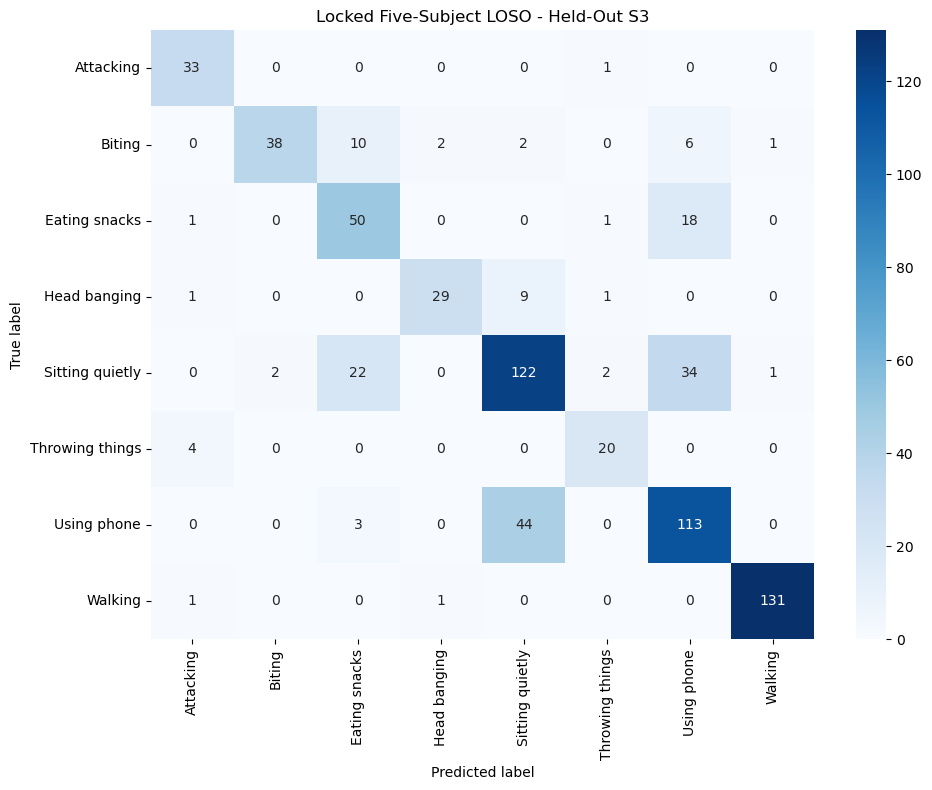

In [31]:
final_s3 = run_loso_fold(five_subject_windows, held_out_subject=3, random_state=RANDOM_STATE)
final_s3.confusion.to_csv(ARTIFACT_DIR / 'final_loso5_confusion_subject_3.csv')
show_fold(final_s3, 'Locked Five-Subject LOSO - Held-Out S3')

### Locked Five-Subject LOSO - Held-Out S4

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,4,4262,716,0.803073,0.831551,0.858859,0.760638,0.986207


,precision,recall,f1-score,support
Attacking,0.771429,1.000000,0.870968,27.000000
Biting,0.611111,0.982143,0.753425,56.000000
Eating snacks,0.866667,0.733871,0.794760,124.000000
Head banging,1.000000,0.973684,0.986667,38.000000
Sitting quietly,0.979381,0.597484,0.742188,159.000000
Throwing things,0.807692,0.875000,0.840000,24.000000
Using phone,0.616162,0.787097,0.691218,155.000000
Walking,0.992188,0.954887,0.973180,133.000000
accuracy,0.803073,0.803073,0.803073,0.803073
macro avg,0.830579,0.863021,0.831551,716.000000


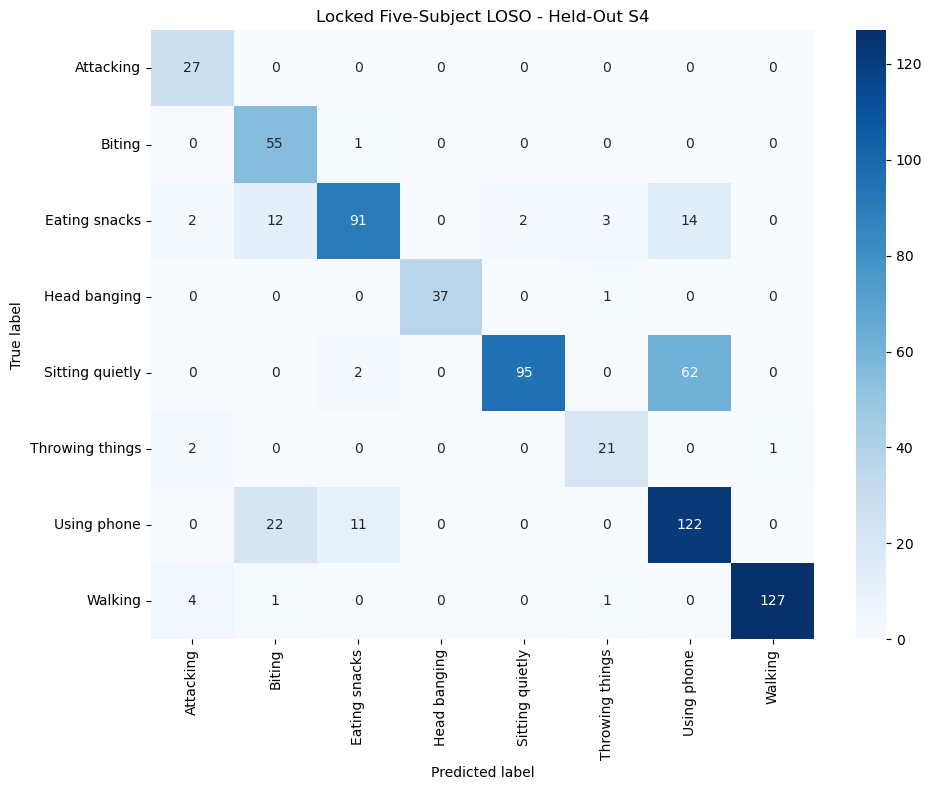

In [32]:
final_s4 = run_loso_fold(five_subject_windows, held_out_subject=4, random_state=RANDOM_STATE)
final_s4.confusion.to_csv(ARTIFACT_DIR / 'final_loso5_confusion_subject_4.csv')
show_fold(final_s4, 'Locked Five-Subject LOSO - Held-Out S4')

### Locked Five-Subject LOSO - Held-Out S5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,4750,471,0.645435,0.697509,0.991453,0.991453,0.991453


,precision,recall,f1-score,support
Attacking,1.000000,0.965517,0.982456,29.000000
Biting,0.973684,0.973684,0.973684,38.000000
Eating snacks,0.402655,0.968085,0.568750,94.000000
Head banging,1.000000,1.000000,1.000000,25.000000
Sitting quietly,0.090909,0.030612,0.045802,98.000000
Throwing things,0.961538,1.000000,0.980392,25.000000
Using phone,1.000000,0.014706,0.028986,68.000000
Walking,1.000000,1.000000,1.000000,94.000000
accuracy,0.645435,0.645435,0.645435,0.645435
macro avg,0.803598,0.744076,0.697509,471.000000


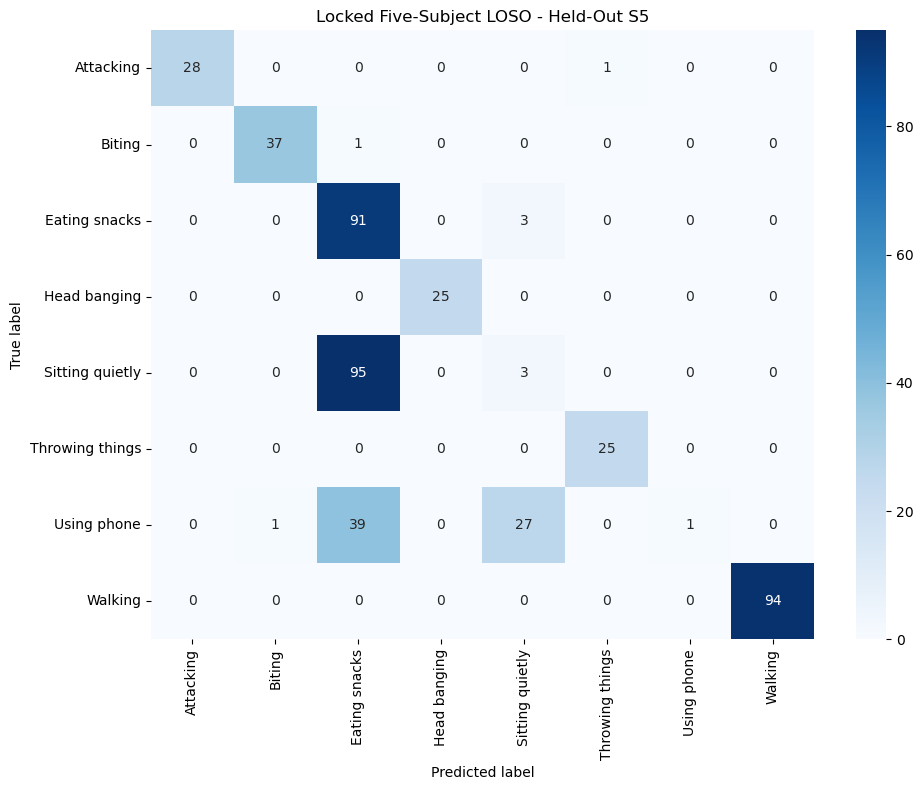

In [33]:
final_s5 = run_loso_fold(five_subject_windows, held_out_subject=5, random_state=RANDOM_STATE)
final_s5.confusion.to_csv(ARTIFACT_DIR / 'final_loso5_confusion_subject_5.csv')
show_fold(final_s5, 'Locked Five-Subject LOSO - Held-Out S5')

In [34]:
final_loso5 = combine_loso_folds([final_s1, final_s2, final_s3, final_s4, final_s5])
final_loso5.fold_metrics.to_csv(ARTIFACT_DIR / 'final_loso5_fold_metrics.csv', index=False)
(ARTIFACT_DIR / 'final_loso5_summary.json').write_text(json.dumps(final_loso5.summary, indent=2), encoding='utf-8')
display(final_loso5.fold_metrics)
display(pd.Series(final_loso5.summary, name='value').to_frame())

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,4732,482,0.531120,0.445423,0.639731,0.536723,0.791667
1,2,4750,472,0.733051,0.680149,0.805970,0.870968,0.750000
2,3,4286,703,0.762447,0.784016,0.877551,0.941606,0.821656
3,4,4262,716,0.803073,0.831551,0.858859,0.760638,0.986207
4,5,4750,471,0.645435,0.697509,0.991453,0.991453,0.991453


,value
mean_fold_accuracy,0.695025
std_fold_accuracy,0.096943
mean_fold_macro_f1,0.687730
mean_fold_abnormal_f1,0.834713
pooled_accuracy,0.709212
pooled_macro_f1,0.727183
pooled_abnormal_f1,0.830022


## 13. Final All-Five Model Export

In [35]:
all_five_windows = concatenate_window_features([five_subject_windows[s] for s in ALL_SUBJECTS])
final_model = fit_estimator(all_five_windows, random_state=RANDOM_STATE)
final_artifact = build_experiment_artifact(
    final_model,
    all_five_windows.x.columns,
    selected_experiment,
    metadata={
        'training_subjects': ALL_SUBJECTS,
        'n_training_windows': len(all_five_windows.y),
        'stage1_selection_summary': comparison.to_dict('records'),
        'five_subject_loso_summary': final_loso5.summary,
    },
)
FINAL_MODEL_PATH = ARTIFACT_DIR / f'final_experiment_{selected_experiment.lower()}_subjects_1_2_3_4_5.joblib'
save_experiment_artifact(FINAL_MODEL_PATH, final_artifact)
final_artifact = load_experiment_artifact(FINAL_MODEL_PATH)
display(pd.Series({
    'selected_experiment': selected_experiment,
    'artifact_path': str(FINAL_MODEL_PATH.resolve()),
    'artifact_bytes': FINAL_MODEL_PATH.stat().st_size,
    'feature_count': len(final_artifact['feature_columns']),
    'training_windows': final_artifact['metadata']['n_training_windows'],
    'five_subject_pooled_accuracy': final_loso5.summary['pooled_accuracy'],
    'five_subject_pooled_abnormal_f1': final_loso5.summary['pooled_abnormal_f1'],
}))

selected_experiment                                                                C
artifact_path                      .\artifact...
artifact_bytes                                                               5154696
feature_count                                                                   2635
training_windows                                                                5695
five_subject_pooled_accuracy                                                0.709212
five_subject_pooled_abnormal_f1                                             0.830022
dtype: object

## 14. Future Work (Not Included in This Ablation)

Future experiments may evaluate graph-based skeleton models, temporal convolution/transformer models, self-supervised pose pretraining, domain-adversarial learning, CORAL-style subject alignment, and confidence-aware temporal decoding. These methods must be compared against the locked A/B/C result in a separate protocol.